In [1]:
# Import polars and set configurations
# *** do not try to open things without "head"***

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# File paths to massive data

HEPG2_PATH = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather"
HEPG2 = pl.read_ipc(HEPG2_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# Volcano plot for RBFOX2 KD events where RBFOX2 is bound at pos 4

In [3]:
# For just HEPG2, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true, and unique rMATS Event ID

filtered_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
    .unique(subset=["rMATS Event ID"])
)

filtered_HEPG2.head(5)



index,AGGF1_1_binding,AKAP1_1_binding,AQR_1_binding,BCCIP_1_binding,BCLAF1_1_binding,BUD13_1_binding,CDC40_1_binding,CSTF2_1_binding,CSTF2T_1_binding,DDX3X_1_binding,DDX52_1_binding,DDX55_1_binding,DDX59_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DKC1_1_binding,DROSHA_1_binding,EFTUD2_1_binding,EIF3D_1_binding,EIF3H_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FKBP4_1_binding,FTO_1_binding,FUBP3_1_binding,FUS_1_binding,FXR2_1_binding,G3BP1_1_binding,GRSF1_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP3_1_binding,ILF3_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,NCBP2_1_binding,NIP7_1_binding,NKRF_1_binding,NOL12_1_binding,NOLC1_1_binding,NSUN2_1_binding,PABPN1_1_binding,PCBP1_1_binding,PCBP2_1_binding,POLR2G_1_binding,PPIG_1_binding,PRPF4_1_binding,PRPF8_1_binding,PTBP1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RBM5_1_binding,RPS3_1_binding,SAFB_1_binding,SDAD1_1_binding,SF3A3_1_binding,SF3B4_1_binding,SFPQ_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,STAU2_1_binding,SUB1_1_binding,SUGP2_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TIAL1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,WDR43_1_binding,XPO5_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,ZC3H11A_1_binding,ZNF800_1_binding,AGGF1_2_binding,AKAP1_2_binding,AQR_2_binding,BCCIP_2_binding,BCLAF1_2_binding,BUD13_2_binding,CDC40_2_binding,CSTF2_2_binding,CSTF2T_2_binding,DDX3X_2_binding,DDX52_2_binding,DDX55_2_binding,DDX59_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DKC1_2_binding,DROSHA_2_binding,EFTUD2_2_binding,EIF3D_2_binding,EIF3H_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FKBP4_2_binding,FTO_2_binding,FUBP3_2_binding,FUS_2_binding,FXR2_2_binding,G3BP1_2_binding,GRSF1_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP3_2_binding,ILF3_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,NCBP2_2_binding,NIP7_2_binding,NKRF_2_binding,NOL12_2_binding,NOLC1_2_binding,NSUN2_2_binding,PABPN1_2_binding,PCBP1_2_binding,PCBP2_2_binding,POLR2G_2_binding,PPIG_2_binding,PRPF4_2_binding,PRPF8_2_binding,PTBP1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RBM5_2_binding,RPS3_2_binding,SAFB_2_binding,SDAD1_2_binding,SF3A3_2_binding,SF3B4_2_binding,SFPQ_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_binding,SRSF1_2_binding,SRSF7_2_binding,SRSF9_2_binding,SSB_2_binding,STAU2_2_binding,SUB1_2_binding,SUGP2_2_binding,SUPV3L1_2_binding,TAF15_2_binding,TARDBP_2_binding,TBRG4_2_binding,TIA1_2_binding,TIAL1_2_binding,TRA2A_2_binding,TROVE2_2_binding,U2AF1_2_binding,U2AF2_2_binding,UCHL5_2_binding,UPF1_2_binding,UTP18_2_binding,WDR43_2_binding,XPO5_2_binding,XRCC6_2_binding,XRN2_2_binding,YBX3_2_binding,ZC3H11A_2_binding,ZNF800_2_binding,AGGF1_3_binding,AKAP1_3_binding,AQR_3_binding,BCCIP_3_binding,BCLAF1_3_binding,BUD13_3_binding,CDC40_3_binding,CSTF2_3_binding,CSTF2T_3_binding,DDX3X_3_binding,DDX52_3_binding,DDX55_3_binding,DDX59_3_binding,DDX6_3_binding,DGCR8_3_binding,DHX30_3_binding,DKC1_3_binding,DROSHA_3_binding,EFTUD2_3_binding,EIF3D_3_binding,EIF3H_3_binding,EXOSC5_3_binding,FAM120A_3_binding,FASTKD2_3_binding,FKBP4_3_binding,FTO_3_binding,FUBP3_3_binding,FUS_3_binding,FXR2_3_binding,G3BP1_3_binding,GRSF1_3_binding,GRWD1_3_binding,GTF2F1_3_binding,HLTF_3_binding,HNRNPA1_3_binding,HNRNPC_3_binding,HNRNPK_3_binding,HNRNPL_3_binding,HNRNPM_3_

In [4]:
# Get rid of unneccessary columns 

columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_4",
    "Raw P-Val",
    "rMATS Event ID"
]

filtered_HEPG2 = filtered_HEPG2.select(columns_to_keep)

In [17]:
# Check


filtered_HEPG2.select(pl.len())
filtered_HEPG2.head()

RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,Raw P-Val,rMATS Event ID
str,str,f64,f64,bool,f64,i64
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.017,true,0.831453,40053
"""RBFOX2""","""RBFOX2_KD-1""",0.000213,-0.379,true,0.000001,36734
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.007,true,0.906517,36712
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.03,true,0.388622,41237
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.005,true,1.0,31041


In [5]:
# convert to Pandas df
df = filtered_HEPG2.to_pandas()
df.head()

,RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,Raw P-Val,rMATS Event ID
0,RBFOX2,RBFOX2_KD-2,1.000000,0.004,True,1.000000,27266
1,RBFOX2,RBFOX2_KD-1,0.299404,-0.027,True,0.043032,5416
2,RBFOX2,RBFOX2_KD-1,0.277910,0.001,True,0.038432,58435
3,RBFOX2,RBFOX2_KD-1,1.000000,0.018,True,0.892929,56262
4,RBFOX2,RBFOX2_KD-1,0.000000,-0.598,True,0.000000,24398


In [6]:
# Log stuff

df["FDR_safe"] = df["FDR"].replace(0, 1e-12)
df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])
np.nanmax(df["neg_log10_FDR"].to_numpy())

12.0

In [7]:
# Colors

def assign_color(row):
    if row["FDR"] >= 0.05 or abs(row["DeltaPSI"]) < 0.05:
        return "gray"
    elif row["DeltaPSI"] >= 0.05:
        return "red"
    elif row["DeltaPSI"] <= -0.05:
        return "blue"
    else:
        return "gray"  # fallback

df["color"] = df.apply(assign_color, axis=1)

counts = df["color"].value_counts().to_dict()
num_points = len(df)

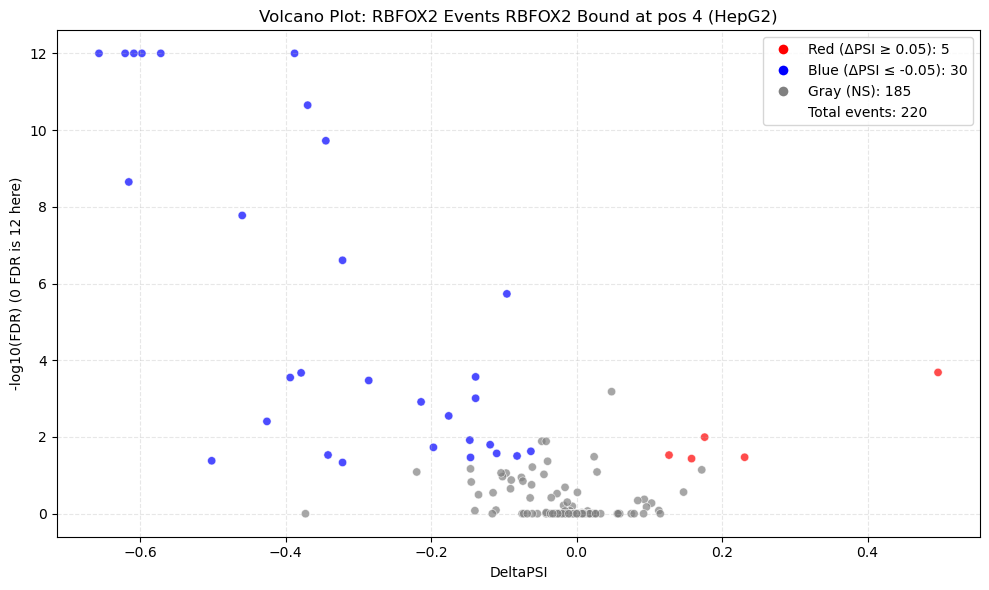

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["DeltaPSI"],
    df["neg_log10_FDR"],
    c=df["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

# Reference lines
#plt.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1, label='FDR = 0.05')
#plt.axvline(0.05, linestyle='--', color='black', linewidth=1)
#plt.axvline(-0.05, linestyle='--', color='black', linewidth=1)

# Build custom legend entries
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="upper right")

# Labels
plt.xlabel("DeltaPSI")
plt.ylabel("-log10(FDR) (0 FDR is 12 here)")
plt.title("Volcano Plot: RBFOX2 Events RBFOX2 Bound at pos 4 (HepG2)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Volcano plots for RBFOX2 KD events where RBFOX2 is bound at pos 4 and not 3 

In [3]:
HEPG2.head(3)

index,AGGF1_1_binding,AKAP1_1_binding,AQR_1_binding,BCCIP_1_binding,BCLAF1_1_binding,BUD13_1_binding,CDC40_1_binding,CSTF2_1_binding,CSTF2T_1_binding,DDX3X_1_binding,DDX52_1_binding,DDX55_1_binding,DDX59_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DKC1_1_binding,DROSHA_1_binding,EFTUD2_1_binding,EIF3D_1_binding,EIF3H_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FKBP4_1_binding,FTO_1_binding,FUBP3_1_binding,FUS_1_binding,FXR2_1_binding,G3BP1_1_binding,GRSF1_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP3_1_binding,ILF3_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,NCBP2_1_binding,NIP7_1_binding,NKRF_1_binding,NOL12_1_binding,NOLC1_1_binding,NSUN2_1_binding,PABPN1_1_binding,PCBP1_1_binding,PCBP2_1_binding,POLR2G_1_binding,PPIG_1_binding,PRPF4_1_binding,PRPF8_1_binding,PTBP1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RBM5_1_binding,RPS3_1_binding,SAFB_1_binding,SDAD1_1_binding,SF3A3_1_binding,SF3B4_1_binding,SFPQ_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,STAU2_1_binding,SUB1_1_binding,SUGP2_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TIAL1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,WDR43_1_binding,XPO5_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,ZC3H11A_1_binding,ZNF800_1_binding,AGGF1_2_binding,AKAP1_2_binding,AQR_2_binding,BCCIP_2_binding,BCLAF1_2_binding,BUD13_2_binding,CDC40_2_binding,CSTF2_2_binding,CSTF2T_2_binding,DDX3X_2_binding,DDX52_2_binding,DDX55_2_binding,DDX59_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DKC1_2_binding,DROSHA_2_binding,EFTUD2_2_binding,EIF3D_2_binding,EIF3H_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FKBP4_2_binding,FTO_2_binding,FUBP3_2_binding,FUS_2_binding,FXR2_2_binding,G3BP1_2_binding,GRSF1_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP3_2_binding,ILF3_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,NCBP2_2_binding,NIP7_2_binding,NKRF_2_binding,NOL12_2_binding,NOLC1_2_binding,NSUN2_2_binding,PABPN1_2_binding,PCBP1_2_binding,PCBP2_2_binding,POLR2G_2_binding,PPIG_2_binding,PRPF4_2_binding,PRPF8_2_binding,PTBP1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RBM5_2_binding,RPS3_2_binding,SAFB_2_binding,SDAD1_2_binding,SF3A3_2_binding,SF3B4_2_binding,SFPQ_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_binding,SRSF1_2_binding,SRSF7_2_binding,SRSF9_2_binding,SSB_2_binding,STAU2_2_binding,SUB1_2_binding,SUGP2_2_binding,SUPV3L1_2_binding,TAF15_2_binding,TARDBP_2_binding,TBRG4_2_binding,TIA1_2_binding,TIAL1_2_binding,TRA2A_2_binding,TROVE2_2_binding,U2AF1_2_binding,U2AF2_2_binding,UCHL5_2_binding,UPF1_2_binding,UTP18_2_binding,WDR43_2_binding,XPO5_2_binding,XRCC6_2_binding,XRN2_2_binding,YBX3_2_binding,ZC3H11A_2_binding,ZNF800_2_binding,AGGF1_3_binding,AKAP1_3_binding,AQR_3_binding,BCCIP_3_binding,BCLAF1_3_binding,BUD13_3_binding,CDC40_3_binding,CSTF2_3_binding,CSTF2T_3_binding,DDX3X_3_binding,DDX52_3_binding,DDX55_3_binding,DDX59_3_binding,DDX6_3_binding,DGCR8_3_binding,DHX30_3_binding,DKC1_3_binding,DROSHA_3_binding,EFTUD2_3_binding,EIF3D_3_binding,EIF3H_3_binding,EXOSC5_3_binding,FAM120A_3_binding,FASTKD2_3_binding,FKBP4_3_binding,FTO_3_binding,FUBP3_3_binding,FUS_3_binding,FXR2_3_binding,G3BP1_3_binding,GRSF1_3_binding,GRWD1_3_binding,GTF2F1_3_binding,HLTF_3_binding,HNRNPA1_3_binding,HNRNPC_3_binding,HNRNPK_3_binding,HNRNPL_3_binding,HNRNPM_3_

In [9]:
# For just HEPG2, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true, has_RBP_KD_3 = false, and unique rMATS Event ID

more_filtered_HEPG2 = (
    HEPG2
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2")
        & (pl.col("has_RBP_KD_4"))
        & (~pl.col("has_RBP_KD_3"))
    )
    .unique(subset=["rMATS Event ID"])
)

more_filtered_HEPG2.head(5)

index,AGGF1_1_binding,AKAP1_1_binding,AQR_1_binding,BCCIP_1_binding,BCLAF1_1_binding,BUD13_1_binding,CDC40_1_binding,CSTF2_1_binding,CSTF2T_1_binding,DDX3X_1_binding,DDX52_1_binding,DDX55_1_binding,DDX59_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DKC1_1_binding,DROSHA_1_binding,EFTUD2_1_binding,EIF3D_1_binding,EIF3H_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FKBP4_1_binding,FTO_1_binding,FUBP3_1_binding,FUS_1_binding,FXR2_1_binding,G3BP1_1_binding,GRSF1_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP3_1_binding,ILF3_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,NCBP2_1_binding,NIP7_1_binding,NKRF_1_binding,NOL12_1_binding,NOLC1_1_binding,NSUN2_1_binding,PABPN1_1_binding,PCBP1_1_binding,PCBP2_1_binding,POLR2G_1_binding,PPIG_1_binding,PRPF4_1_binding,PRPF8_1_binding,PTBP1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RBM5_1_binding,RPS3_1_binding,SAFB_1_binding,SDAD1_1_binding,SF3A3_1_binding,SF3B4_1_binding,SFPQ_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,STAU2_1_binding,SUB1_1_binding,SUGP2_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TIAL1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,WDR43_1_binding,XPO5_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,ZC3H11A_1_binding,ZNF800_1_binding,AGGF1_2_binding,AKAP1_2_binding,AQR_2_binding,BCCIP_2_binding,BCLAF1_2_binding,BUD13_2_binding,CDC40_2_binding,CSTF2_2_binding,CSTF2T_2_binding,DDX3X_2_binding,DDX52_2_binding,DDX55_2_binding,DDX59_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DKC1_2_binding,DROSHA_2_binding,EFTUD2_2_binding,EIF3D_2_binding,EIF3H_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FKBP4_2_binding,FTO_2_binding,FUBP3_2_binding,FUS_2_binding,FXR2_2_binding,G3BP1_2_binding,GRSF1_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP3_2_binding,ILF3_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,NCBP2_2_binding,NIP7_2_binding,NKRF_2_binding,NOL12_2_binding,NOLC1_2_binding,NSUN2_2_binding,PABPN1_2_binding,PCBP1_2_binding,PCBP2_2_binding,POLR2G_2_binding,PPIG_2_binding,PRPF4_2_binding,PRPF8_2_binding,PTBP1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RBM5_2_binding,RPS3_2_binding,SAFB_2_binding,SDAD1_2_binding,SF3A3_2_binding,SF3B4_2_binding,SFPQ_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_binding,SRSF1_2_binding,SRSF7_2_binding,SRSF9_2_binding,SSB_2_binding,STAU2_2_binding,SUB1_2_binding,SUGP2_2_binding,SUPV3L1_2_binding,TAF15_2_binding,TARDBP_2_binding,TBRG4_2_binding,TIA1_2_binding,TIAL1_2_binding,TRA2A_2_binding,TROVE2_2_binding,U2AF1_2_binding,U2AF2_2_binding,UCHL5_2_binding,UPF1_2_binding,UTP18_2_binding,WDR43_2_binding,XPO5_2_binding,XRCC6_2_binding,XRN2_2_binding,YBX3_2_binding,ZC3H11A_2_binding,ZNF800_2_binding,AGGF1_3_binding,AKAP1_3_binding,AQR_3_binding,BCCIP_3_binding,BCLAF1_3_binding,BUD13_3_binding,CDC40_3_binding,CSTF2_3_binding,CSTF2T_3_binding,DDX3X_3_binding,DDX52_3_binding,DDX55_3_binding,DDX59_3_binding,DDX6_3_binding,DGCR8_3_binding,DHX30_3_binding,DKC1_3_binding,DROSHA_3_binding,EFTUD2_3_binding,EIF3D_3_binding,EIF3H_3_binding,EXOSC5_3_binding,FAM120A_3_binding,FASTKD2_3_binding,FKBP4_3_binding,FTO_3_binding,FUBP3_3_binding,FUS_3_binding,FXR2_3_binding,G3BP1_3_binding,GRSF1_3_binding,GRWD1_3_binding,GTF2F1_3_binding,HLTF_3_binding,HNRNPA1_3_binding,HNRNPC_3_binding,HNRNPK_3_binding,HNRNPL_3_binding,HNRNPM_3_

In [10]:
# Check number of events

more_filtered_HEPG2.select(pl.len())

len
u32
181


In [11]:
# Filter the dataframe for relavent columns

new_columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_4",
    "has_RBP_KD_3",
    "Raw P-Val",
    "rMATS Event ID"
]

more_filtered_HEPG2 = more_filtered_HEPG2.select(new_columns_to_keep)

# Check for correct columns
more_filtered_HEPG2.head()

RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,has_RBP_KD_3,Raw P-Val,rMATS Event ID
str,str,f64,f64,bool,bool,f64,i64
"""RBFOX2""","""RBFOX2_KD-1""",0.012943,-0.048,true,false,0.000359,15090
"""RBFOX2""","""RBFOX2_KD-1""",0.023625,-0.063,true,false,0.000916,1345
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.075,true,false,0.946801,34734
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.024,true,false,0.313542,51523
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.001,true,false,1.0,58442


In [12]:
# Pandas and FDR

df_2 = more_filtered_HEPG2.to_pandas()
df_2.head()

df_2["FDR_safe"] = df_2["FDR"].replace(0, 1e-12)
df_2["neg_log10_FDR"] = -np.log10(df_2["FDR_safe"])
np.nanmax(df_2["neg_log10_FDR"].to_numpy())

12.0

In [13]:
# Colors

df_2["color"] = df_2.apply(assign_color, axis=1)

counts = df_2["color"].value_counts().to_dict()
num_points = len(df_2)

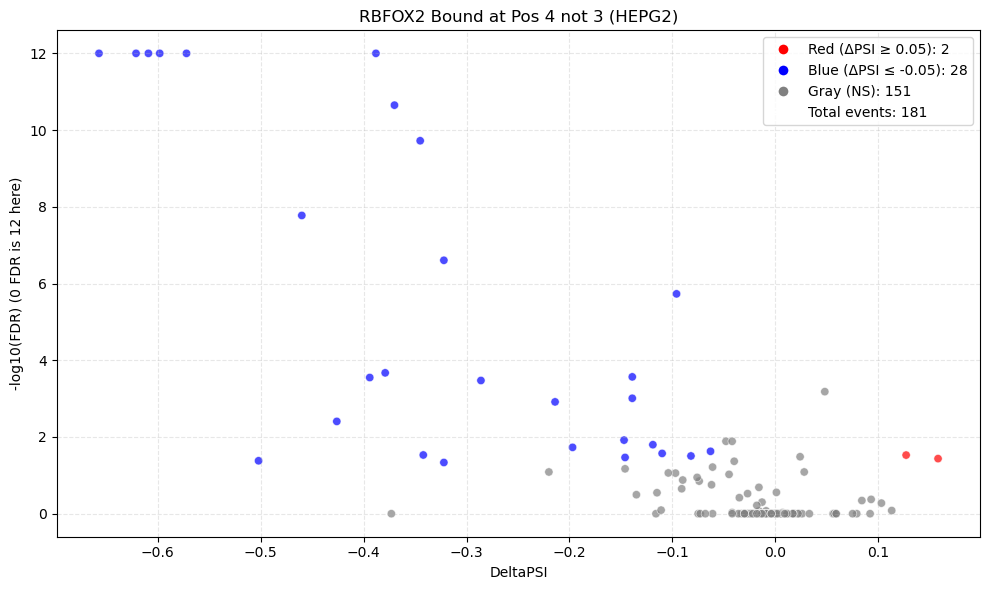

In [14]:
# Volcano plot

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_2["DeltaPSI"],
    df_2["neg_log10_FDR"],
    c=df_2["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

# Reference lines
#plt.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1, label='FDR = 0.05')
#plt.axvline(0.05, linestyle='--', color='black', linewidth=1)
#plt.axvline(-0.05, linestyle='--', color='black', linewidth=1)

# Build custom legend entries
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="upper right")

# Labels
plt.xlabel("DeltaPSI")
plt.ylabel("-log10(FDR) (0 FDR is 12 here)")
plt.title("RBFOX2 Bound at Pos 4 not 3 (HEPG2)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()